THIS IS A SAMPLE PROJECT TO PERFORM EXPLORATORY DATA ANALYSIS OF A DATASET WITH 1500 ROWS


Importing Pandas

In [128]:
import pandas as pd


IMPORTING DATASET

In [129]:

df=df = pd.read_csv("data/sales_dataset.csv")

VIEWING THE FILE

In [130]:

df

,Date,Region,Salesperson,Product,Category,Units Sold,Unit Price,Total Revenue,Customer Rating
0,2026-02-21,Ibadan,Ibrahim,Charger,Accessories,7,20,140,5
1,2026-03-13,Lagos,Bola,Laptop,Electronics,15,800,12000,5
2,2026-03-24,Ibadan,Luke,Charger,Accessories,7,20,140,3
3,2026-03-29,Port Harcourt,Ngozi,Charger,Accessories,11,20,220,5
4,2026-01-24,Port Harcourt,Hauwa,Tablet,Electronics,4,300,1200,3
...,...,...,...,...,...,...,...,...,...
1495,2026-01-15,Kano,Bola,Headphones,Accessories,3,50,150,5
1496,2026-02-04,Ibadan,Ibrahim,Headphones,Accessories,13,50,650,4
1497,2026-02-28,Ibadan,Hauwa,Laptop,Electronics,11,800,8800,5
1498,2026-02-23,Lagos,Bola,Tablet,Electronics,19,300,5700,3


CHECKING UNIQUE PRODUCTS

In [131]:

unique_products = df['Product'].unique()

print(f"Total Number of Unique Products: {len(unique_products)}")
print("=" * 40)
for i, product in enumerate(sorted(unique_products), 1):
    print(f"{i}. {product}")

Total Number of Unique Products: 5
1. Charger
2. Headphones
3. Laptop
4. Phone
5. Tablet


TOP PRODUCTS BY TOTAL REVENUE

In [132]:

top_products = (
    df.groupby('Product')['Total Revenue']
    .sum()
    .reset_index()
    .sort_values('Total Revenue', ascending=False)
    .head(10)
    .reset_index(drop=True)
)
top_products.index += 1

# Format for display
top_products['Total Revenue'] = top_products['Total Revenue'].apply(lambda x: f"₦{x:,.0f}")

print("Top Products by Total Revenue")
print("=" * 40)
print(top_products.to_string())

Top Products by Total Revenue
      Product Total Revenue
1      Laptop    ₦2,844,800
2      Tablet    ₦1,002,900
3       Phone      ₦733,000
4  Headphones      ₦143,250
5     Charger       ₦61,900


IMPORTING VISUALIZATION TOOLS

In [133]:
#importing visualisation tools
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

CHART OF TOP PRODUCTS BY TOTAL REVENUE

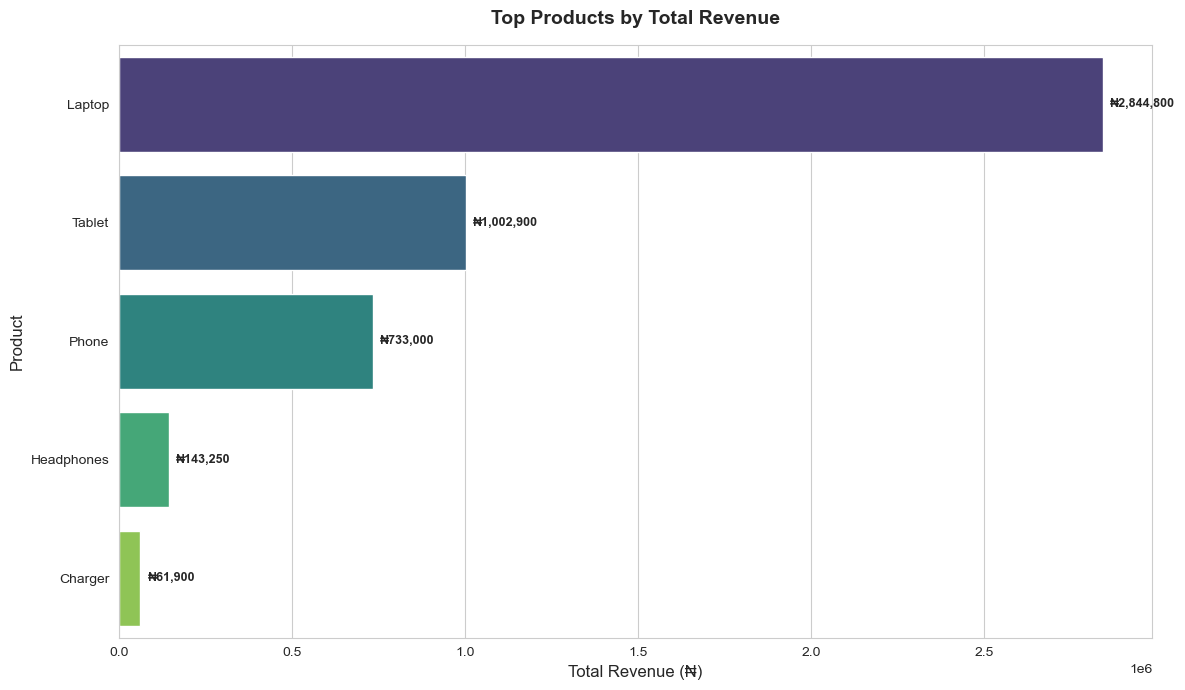

In [134]:

top_prod_plot = (
    df.groupby('Product')['Total Revenue']
    .sum()
    .reset_index()
    .sort_values('Total Revenue', ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

sns.barplot(
    data=top_prod_plot,
    x='Total Revenue',
    y='Product',
    hue='Product',
    palette='viridis',
    legend=False
)

# Value labels on bars
for p in plt.gca().patches:
    plt.gca().annotate(
        f'₦{p.get_width():,.0f}',
        (p.get_width(), p.get_y() + p.get_height() / 2.),
        xytext=(5, 0),
        textcoords='offset points',
        va='center', fontsize=9, fontweight='bold'
    )

plt.title('Top Products by Total Revenue', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Total Revenue (₦)', fontsize=12)
plt.ylabel('Product', fontsize=12)
plt.tight_layout()
plt.savefig('top_products_revenue.png', dpi=150, bbox_inches='tight')
plt.show()


TOTAL REVENUE PER PRODUCT

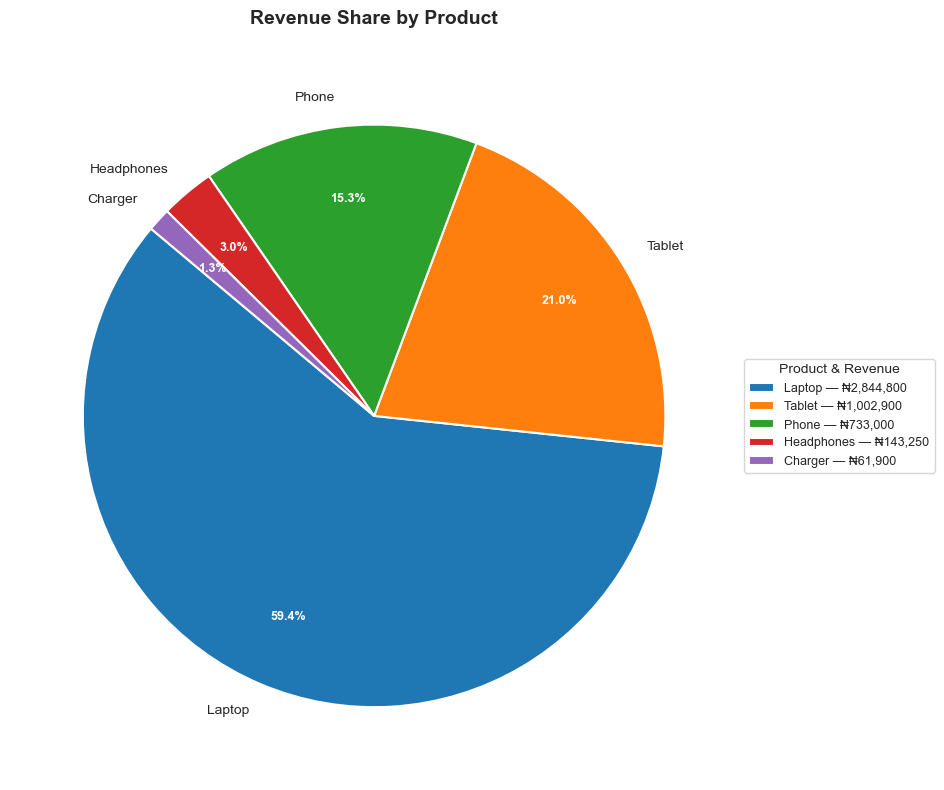

In [135]:

product_revenue = (
    df.groupby('Product')['Total Revenue']
    .sum()
    .reset_index()
    .sort_values('Total Revenue', ascending=False)
)
# Pie Chart
plt.figure(figsize=(12, 8))

colors = plt.cm.tab10.colors

wedges, texts, autotexts = plt.pie(
    product_revenue['Total Revenue'],
    labels=product_revenue['Product'],
    autopct='%1.1f%%',
    colors=colors,
    startangle=140,
    pctdistance=0.75,
    wedgeprops=dict(edgecolor='white', linewidth=1.5),
    textprops=dict(fontsize=10)
)

# Bold percentage labels
for autotext in autotexts:
    autotext.set_fontsize(9)
    autotext.set_fontweight('bold')
    autotext.set_color('white')

# Add revenue to legend
legend_labels = [
    f"{row['Product']} — ₦{row['Total Revenue']:,.0f}"
    for _, row in product_revenue.iterrows()
]
plt.legend(
    wedges,
    legend_labels,
    title='Product & Revenue',
    loc='center left',
    bbox_to_anchor=(1, 0, 0.5, 1),
    fontsize=9
)

plt.title('Revenue Share by Product', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('reveue share by product.png', dpi=150, bbox_inches='tight')
plt.show()


UNITS OF EACH PRODUCT SOLD


In [136]:

units_per_product = (
    df.groupby('Product')['Units Sold']
    .sum()
    .reset_index()
    .sort_values('Units Sold', ascending=False)
    .reset_index(drop=True)
)
units_per_product.index += 1

# Print Table
print("Units Sold per Product")
print("=" * 35)
print(units_per_product.to_string())


Units Sold per Product
      Product  Units Sold
1      Laptop        3556
2      Tablet        3343
3     Charger        3095
4       Phone        2932
5  Headphones        2865


CHART OF UNITS SOLD PER PRODUCT

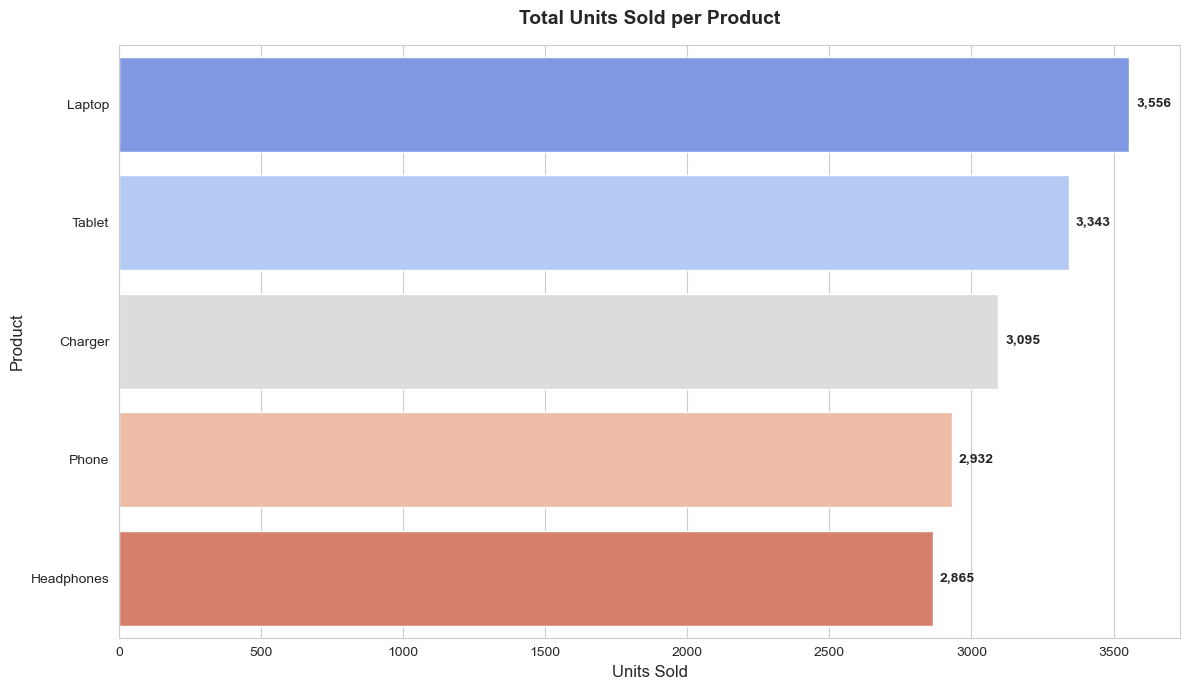

In [137]:

plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

sns.barplot(
    data=units_per_product,
    x='Units Sold',
    y='Product',
    hue='Product',
    palette='coolwarm',
    legend=False
)

# Value labels on bars
for p in plt.gca().patches:
    plt.gca().annotate(
        f'{int(p.get_width()):,}',
        (p.get_width(), p.get_y() + p.get_height() / 2.),
        xytext=(5, 0),
        textcoords='offset points',
        va='center', fontsize=10, fontweight='bold'
    )

plt.title('Total Units Sold per Product', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Units Sold', fontsize=12)
plt.ylabel('Product', fontsize=12)
plt.tight_layout()
plt.savefig('Units per product.png', dpi=150, bbox_inches='tight')
plt.show()


REGIONAL ANALYSIS

UNITS SOLD PER REGION

In [138]:

units_per_region = (
    df.groupby('Region')['Units Sold']
    .sum()
    .reset_index()
    .sort_values('Units Sold', ascending=False)
    .reset_index(drop=True)
)
units_per_region.index += 1

# Highlight top region
top_region = units_per_region.iloc[0]

print("Units Sold per Region")
print("=" * 35)
print(units_per_region.to_string())
print()


Units Sold per Region
          Region  Units Sold
1          Lagos        3471
2  Port Harcourt        3224
3          Abuja        3041
4           Kano        3033
5         Ibadan        3022



CCHART OF UNITS SOLD PER REGION

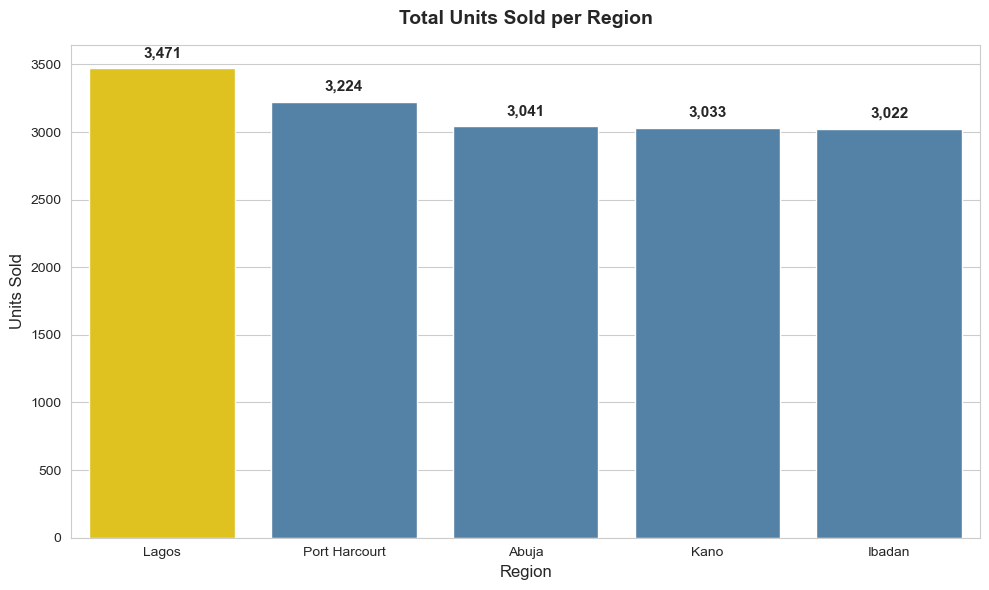

In [139]:

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# Highlight the top region with a different color
colors = ['gold' if r == top_region['Region'] else 'steelblue' for r in units_per_region['Region']]

sns.barplot(
    data=units_per_region,
    x='Region',
    y='Units Sold',
    palette=colors,
    hue='Region',
    legend=False
)

# Value labels on bars
for p in plt.gca().patches:
    plt.gca().annotate(
        f'{int(p.get_height()):,}',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        xytext=(0, 8),
        textcoords='offset points',
        ha='center', fontsize=11, fontweight='bold'
    )

plt.title('Total Units Sold per Region', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Region', fontsize=12)
plt.ylabel('Units Sold', fontsize=12)
plt.tight_layout()
plt.savefig('Units sold per region.png', dpi=150, bbox_inches='tight')
plt.show()


PIE CHART OF UNITS SOLD PER REGION

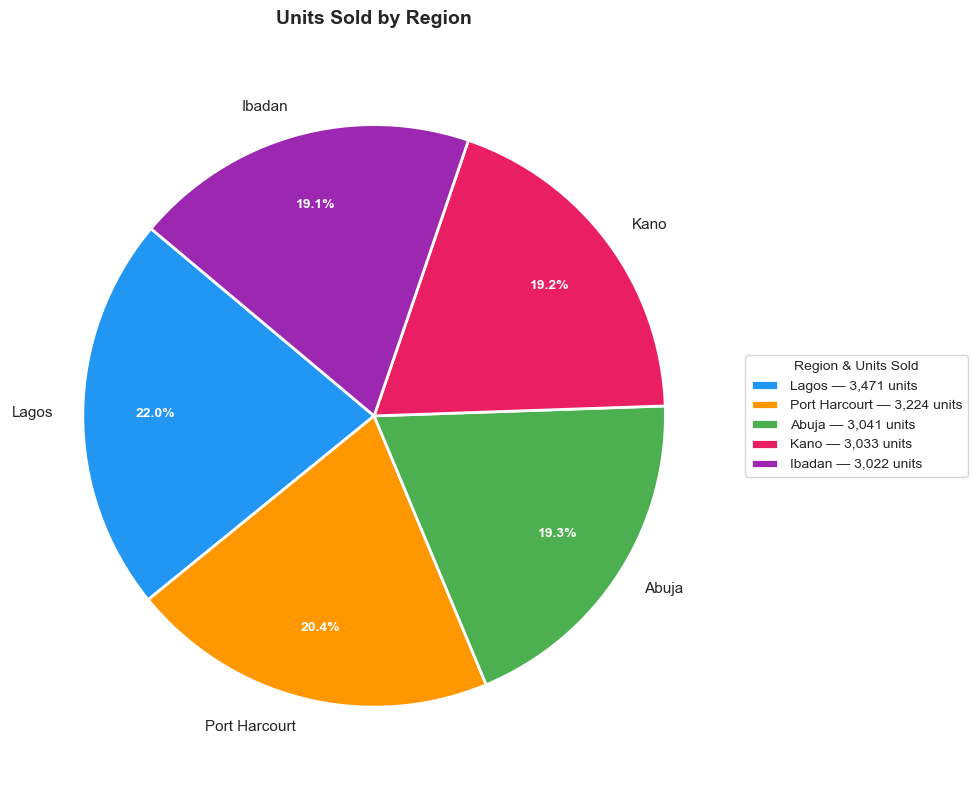

In [140]:

plt.figure(figsize=(10, 8))

colors = ['#2196F3', '#FF9800', '#4CAF50', '#E91E63', '#9C27B0']

wedges, texts, autotexts = plt.pie(
    units_per_region['Units Sold'],
    labels=units_per_region['Region'],
    autopct='%1.1f%%',
    colors=colors[:len(units_per_region)],
    startangle=140,
    pctdistance=0.75,
    wedgeprops=dict(edgecolor='white', linewidth=2),
    textprops=dict(fontsize=11)
)

# Bold percentage labels
for autotext in autotexts:
    autotext.set_fontsize(10)
    autotext.set_fontweight('bold')
    autotext.set_color('white')

# Legend with units sold
legend_labels = [
    f"{row['Region']} — {row['Units Sold']:,} units"
    for _, row in units_per_region.iterrows()
]
plt.legend(
    wedges,
    legend_labels,
    title='Region & Units Sold',
    loc='center left',
    bbox_to_anchor=(1, 0, 0.5, 1),
    fontsize=10
)

plt.title('Units Sold by Region', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('units_sold_region_pie.png', dpi=150, bbox_inches='tight')
plt.show()

Revenue generated per region

In [141]:

revenue_per_region = (
    df.groupby('Region')['Total Revenue']
    .sum()
    .reset_index()
    .sort_values('Total Revenue', ascending=False)
    .reset_index(drop=True)
)
revenue_per_region.index += 1

print("Revenue per Region")
print("=" * 35)
print(revenue_per_region.to_string())


Revenue per Region
          Region  Total Revenue
1          Lagos        1050420
2         Ibadan         958720
3  Port Harcourt         942050
4           Kano         920400
5          Abuja         914260


CHART OF REVENUE GENERATED PER REGION

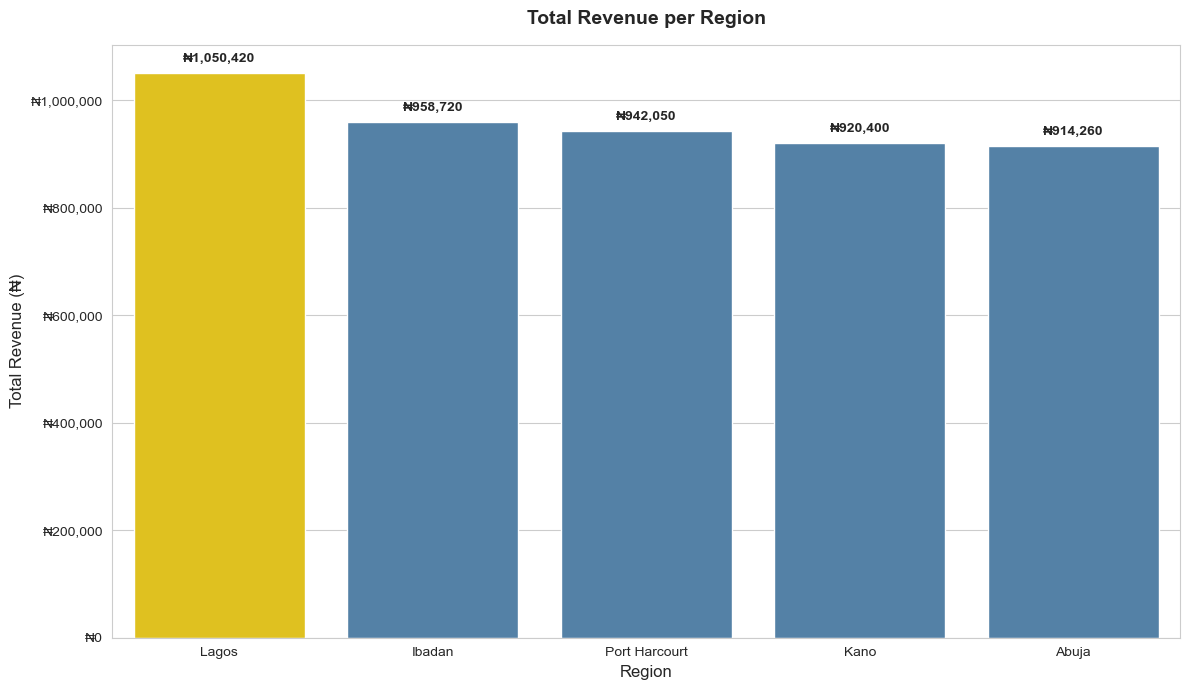

In [142]:

plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

# Highlight top region in gold
colors = ['gold' if r == top_region['Region'] else 'steelblue' for r in revenue_per_region['Region']]

sns.barplot(
    data=revenue_per_region,
    x='Region',
    y='Total Revenue',
    hue='Region',
    palette=colors,
    legend=False
)

# Remove exponential notation on Y-axis
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'₦{x:,.0f}'))

# Value labels on bars
for p in plt.gca().patches:
    height = p.get_height()
    if height > 0:
        plt.gca().annotate(
            f'₦{height:,.0f}',
            (p.get_x() + p.get_width() / 2., height),
            xytext=(0, 8),
            textcoords='offset points',
            ha='center', fontsize=10, fontweight='bold'
        )

plt.title('Total Revenue per Region', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Region', fontsize=12)
plt.ylabel('Total Revenue (₦)', fontsize=12)
plt.tight_layout()
plt.savefig('revenue_per_region.png', dpi=150, bbox_inches='tight')
plt.show()

REVENUE BREAKDOWN BY REGION AND CATEGORY

In [143]:

revenue_breakdown = (
    df.groupby(['Region', 'Category'])['Total Revenue']
    .sum()
    .reset_index()
    .sort_values('Total Revenue', ascending=False)
)
# Pivot for clean table display
pivot_table = revenue_breakdown.pivot(index='Region', columns='Category', values='Total Revenue').fillna(0)
pivot_table['Grand Total'] = pivot_table.sum(axis=1)
pivot_table.loc['Total'] = pivot_table.sum()

# Format with ₦ and commas
pivot_formatted = pivot_table.map(lambda x: f"₦{x:,.0f}")

print("Revenue Breakdown by Region and Category")
print("=" * 70)
print(pivot_formatted.to_string())


Revenue Breakdown by Region and Category
Category      Accessories Electronics Grand Total
Region                                           
Abuja             ₦38,310    ₦875,950    ₦914,260
Ibadan            ₦35,120    ₦923,600    ₦958,720
Kano              ₦40,050    ₦880,350    ₦920,400
Lagos             ₦47,270  ₦1,003,150  ₦1,050,420
Port Harcourt     ₦44,400    ₦897,650    ₦942,050
Total            ₦205,150  ₦4,580,700  ₦4,785,850


CHART REVENUE BREAKDOWN BY REGION AND CATEGORY

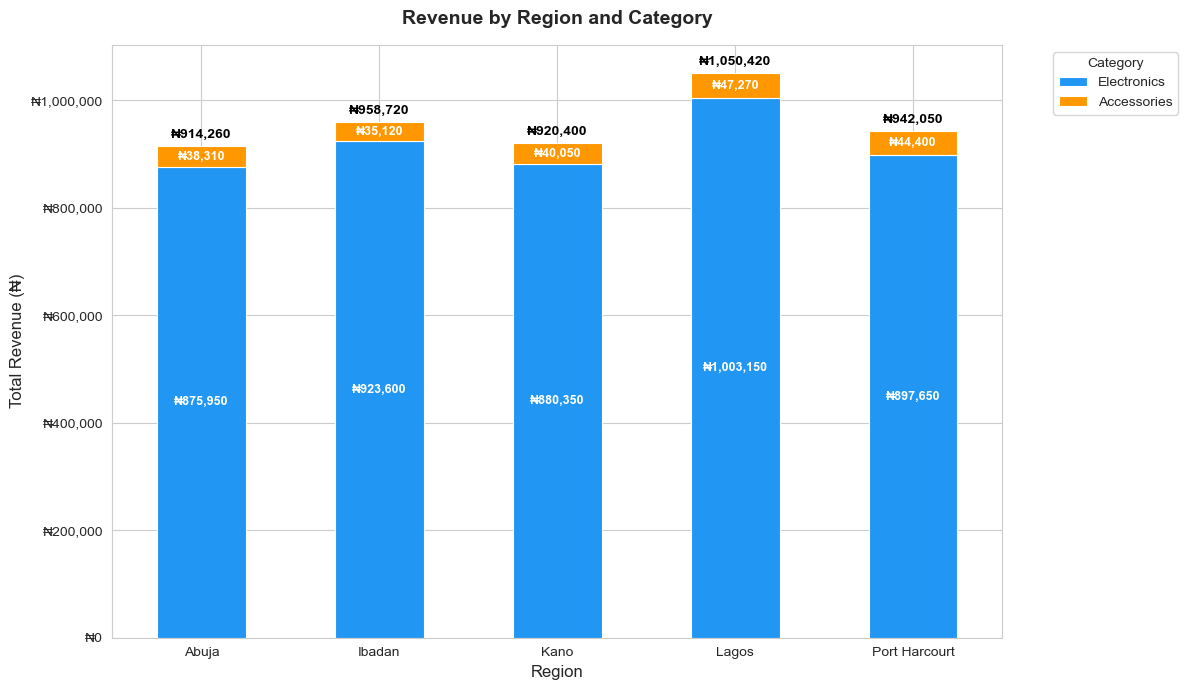

In [144]:


pivot = revenue_breakdown.pivot(index='Region', columns='Category', values='Total Revenue').fillna(0)

fig, ax = plt.subplots(figsize=(12, 7))
sns.set_style("whitegrid")

colors = ['#2196F3', '#FF9800', '#4CAF50', '#E91E63', '#9C27B0']
pivot = pivot[['Electronics', 'Accessories']]
pivot.plot(
    kind='bar',
    stacked=True,
    ax=ax,
    color=colors[:len(pivot.columns)],
    edgecolor='white',
    linewidth=0.8,
    width=0.5
)

# Remove scientific notation on Y-axis
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'₦{x:,.0f}'))

# Value labels inside each segment
for bar_group in ax.containers:
    for bar in bar_group:
        height = bar.get_height()
        if height > 0:
            ax.annotate(
                f'₦{height:,.0f}',
                xy=(bar.get_x() + bar.get_width() / 2, bar.get_y() + height / 2),
                ha='center', va='center',
                fontsize=9, fontweight='bold', color='white'
            )

# Grand total labels on top of each bar
for i, region in enumerate(pivot.index):
    total = pivot.loc[region].sum()
    ax.annotate(
        f'₦{total:,.0f}',
        xy=(i, total),
        xytext=(0, 6),
        textcoords='offset points',
        ha='center', fontsize=10, fontweight='bold', color='black'
    )

ax.set_title('Revenue by Region and Category', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Region', fontsize=12)
ax.set_ylabel('Total Revenue (₦)', fontsize=12)
ax.tick_params(axis='x', rotation=0)
ax.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.savefig('Revenue by region.png', dpi=150, bbox_inches='tight')
plt.show()


MONTHLY ANALYSIS

MONTHLY REVENUE

In [145]:
# Parse Date column
df['Date'] = pd.to_datetime(df['Date'])

# Extract Month Name and Period for sorting
df['Month'] = df['Date'].dt.to_period('M')
df['Month Name'] = df['Date'].dt.strftime('%B %Y')

# Aggregate Total Revenue per Month
monthly_revenue = (
    df.groupby(['Month', 'Month Name'])['Total Revenue']
    .sum()
    .reset_index()
    .sort_values('Total Revenue', ascending=False)
    .reset_index(drop=True)
)
monthly_revenue.index += 1

# Drop the Period column for clean display
monthly_revenue = monthly_revenue.drop(columns=['Month'])

# Format Revenue
monthly_revenue['Total Revenue'] = monthly_revenue['Total Revenue'].apply(lambda x: f"₦{x:,.0f}")

# Rename columns
monthly_revenue.columns = ['Month', 'Total Revenue']

print(monthly_revenue.to_string())
print()

           Month Total Revenue
1     March 2026    ₦1,708,390
2  February 2026    ₦1,630,820
3   January 2026    ₦1,446,640



CHART OF MONTHLY REVENUE

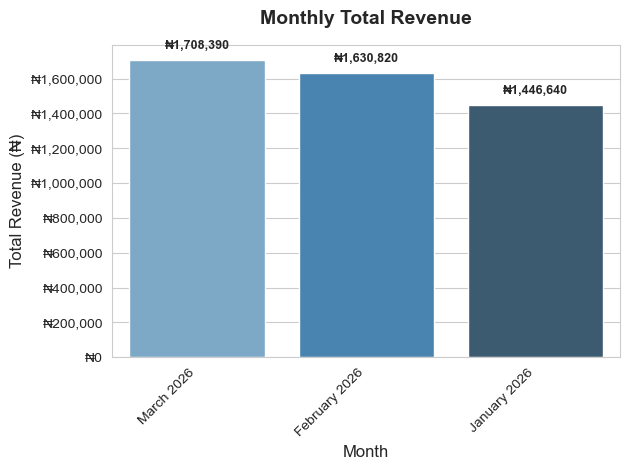

In [146]:
# Bar Chart 
df['Date'] = pd.to_datetime(df['Date'])

# Extract Month Name and Period for sorting
df['Month'] = df['Date'].dt.to_period('M')
df['Month Name'] = df['Date'].dt.strftime('%B %Y')

# Aggregate Total Revenue per Month
monthly_revenue = (
    df.groupby(['Month', 'Month Name'])['Total Revenue']
    .sum()
    .reset_index()
    .sort_values('Total Revenue', ascending=False)
    .reset_index(drop=True)
)
sns.barplot(
    data=monthly_revenue,
    x='Month Name',
    y='Total Revenue',
    hue='Month Name',
    palette='Blues_d',
    legend=False
)

# Remove scientific notation on Y-axis
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'₦{x:,.0f}'))

# Value labels on bars
for p in plt.gca().patches:
    height = p.get_height()
    if height > 0:
        plt.gca().annotate(
            f'₦{height:,.0f}',
            (p.get_x() + p.get_width() / 2., height),
            xytext=(0, 8),
            textcoords='offset points',
            ha='center', fontsize=9, fontweight='bold'
        )

plt.title('Monthly Total Revenue', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total Revenue (₦)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('monthly_revenue_bar.png', dpi=150, bbox_inches='tight')
plt.show()


SALESPERSON ANALYSIS

AVERAGE CUSTOMER RATING PER SALESPERSON

In [147]:

avg_rating = (
    df.groupby('Salesperson')['Customer Rating']
    .mean()
    .reset_index()
    .sort_values('Customer Rating', ascending=False)
    .reset_index(drop=True)
)

avg_rating.columns = ['Salesperson', 'Avg Customer Rating']
avg_rating['Avg Customer Rating'] = avg_rating['Avg Customer Rating'].round(2)
avg_rating.index += 1  # Rank starts from 1

print("Salespersons Ranked by Average Customer Rating")
print("=" * 45)
print(avg_rating.to_string())

Salespersons Ranked by Average Customer Rating
   Salesperson  Avg Customer Rating
1         Kemi                 3.20
2         Luke                 3.13
3          Ola                 3.11
4      Ibrahim                 3.10
5       Gideon                 3.07
6        Ngozi                 3.05
7         Dami                 3.03
8        Hauwa                 3.01
9        Emeka                 2.99
10        Bola                 2.98
11        Mary                 2.96
12         Joy                 2.82
13      Fatima                 2.81
14         Ade                 2.74
15       Chidi                 2.67


THE EFFECT OF CUSTOMER RATING ON TOTAL TRANSACTIONS

In [148]:

avg_rating = (
    df.groupby('Salesperson')['Customer Rating']
    .mean()
    .reset_index()
)

# Number of Transactions per Salesperson
transaction_count = (
    df.groupby('Salesperson')['Customer Rating']
    .count()
    .reset_index()
)
transaction_count.columns = ['Salesperson', 'Total Transactions']

# Merge both
combined = avg_rating.merge(transaction_count, on='Salesperson')
combined.columns = ['Salesperson', 'Avg Customer Rating', 'Total Transactions']
combined['Avg Customer Rating'] = combined['Avg Customer Rating'].round(2)

# Sort by Average Customer Rating
combined = (
    combined
    .sort_values('Avg Customer Rating', ascending=False)
    .reset_index(drop=True)
)
combined.index += 1  # Rank starts from 1

# Highlight top salesperson by transactions
top_transactions = combined.loc[combined['Total Transactions'].idxmax(), 'Salesperson']
top_count = combined['Total Transactions'].max()

print("Salespersons Ranked by Average Customer Rating (with Transaction Count)")
print("=" * 70)
print(combined.to_string())



Salespersons Ranked by Average Customer Rating (with Transaction Count)
   Salesperson  Avg Customer Rating  Total Transactions
1         Kemi                 3.20                  91
2         Luke                 3.13                 112
3          Ola                 3.11                  98
4      Ibrahim                 3.10                 113
5       Gideon                 3.07                  91
6        Ngozi                 3.05                 101
7         Dami                 3.03                 107
8        Hauwa                 3.01                 106
9        Emeka                 2.99                  88
10        Bola                 2.98                 120
11        Mary                 2.96                  98
12         Joy                 2.82                  89
13      Fatima                 2.81                  97
14         Ade                 2.74                  95
15       Chidi                 2.67                  94


CHART OF THE EFFECT OF CUSTOMER RATING ON TOTAL TRANSACTIONS

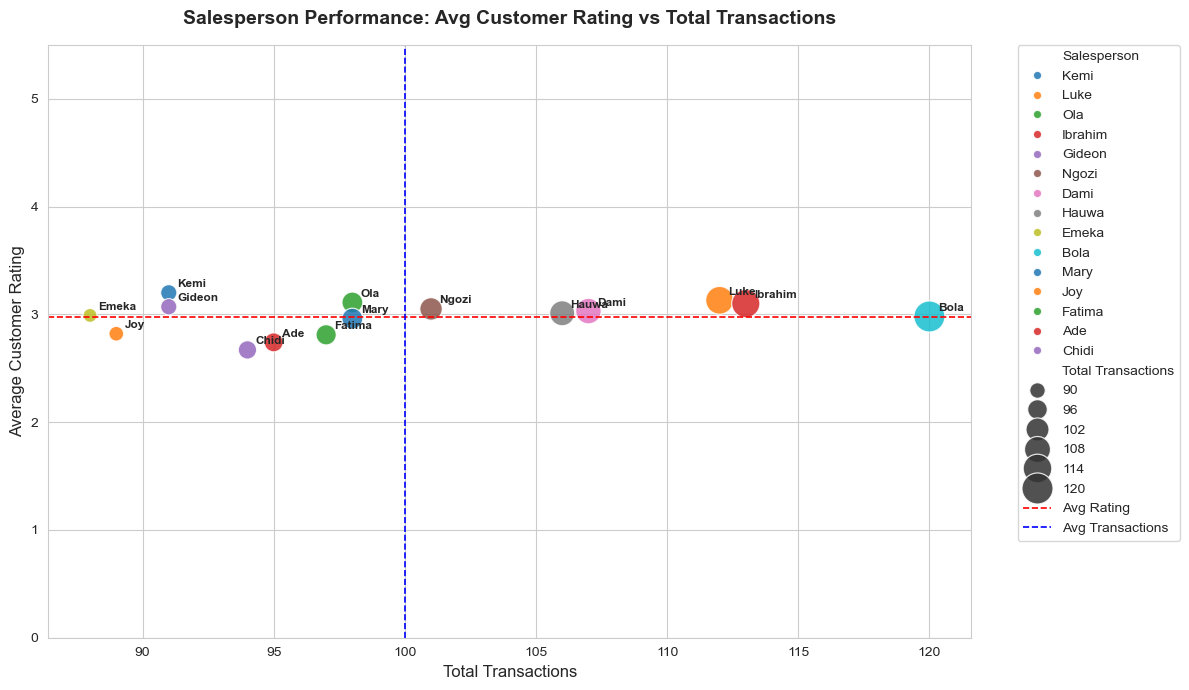

In [149]:
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

scatter = sns.scatterplot(
    data=combined,
    x='Total Transactions',
    y='Avg Customer Rating',
    hue='Salesperson',
    size='Total Transactions',
    sizes=(100, 500),
    palette='tab10',
    alpha=0.85
)

# Annotate each point with salesperson name
for _, row in combined.iterrows():
    plt.annotate(
        row['Salesperson'],
        xy=(row['Total Transactions'], row['Avg Customer Rating']),
        xytext=(6, 4),
        textcoords='offset points',
        fontsize=8.5,
        fontweight='bold'
    )

# Reference lines for averages
plt.axhline(y=combined['Avg Customer Rating'].mean(), color='red', linestyle='--', linewidth=1.2, label='Avg Rating')
plt.axvline(x=combined['Total Transactions'].mean(), color='blue', linestyle='--', linewidth=1.2, label='Avg Transactions')

plt.title('Salesperson Performance: Avg Customer Rating vs Total Transactions',
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Total Transactions', fontsize=12)
plt.ylabel('Average Customer Rating', fontsize=12)
plt.ylim(0, 5.5)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

plt.tight_layout()
plt.savefig('salesperson_scatterplot.png', dpi=150, bbox_inches='tight')
plt.show()
